# Network Analysis of Chronic Disease Comorbidities

### Objective
In this notebook, we analyze:
- Which chronic diseases often occur together?
- What their relationship/interaction patterns are like
- Which diseases are central (most connected)?
- Which combinations significantly increase health risks?
 
### We analyze a network built from four chronic conditions:
- High Blood Pressure (HighBP)
- High Cholesterol (HighChol)
- Stroke
- Heart Disease / Heart Attack

These conditions commonly co-occur and influence long-term health outcomes.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import os

plt.style.use("seaborn-v0_8")

In [2]:
data = pd.read_csv("../data/processed/cleaned_data.csv")
data.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore,HealthBurden
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3,9.0
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3,5.5
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2,6.8
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0,3.7
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0,4.4


In [3]:
disease_cols = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']

df_disease = data[disease_cols]
df_disease.head()

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
0,1,1,0,0
1,0,0,0,0
2,1,1,0,0
3,1,0,0,0
4,1,1,0,0


In [4]:
co_matrix = df_disease.T.dot(df_disease)
co_matrix

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
HighBP,104422,62276,7617,17784
HighChol,62276,101508,6649,16597
Stroke,7617,6649,10284,3936
HeartDiseaseorAttack,17784,16597,3936,23717


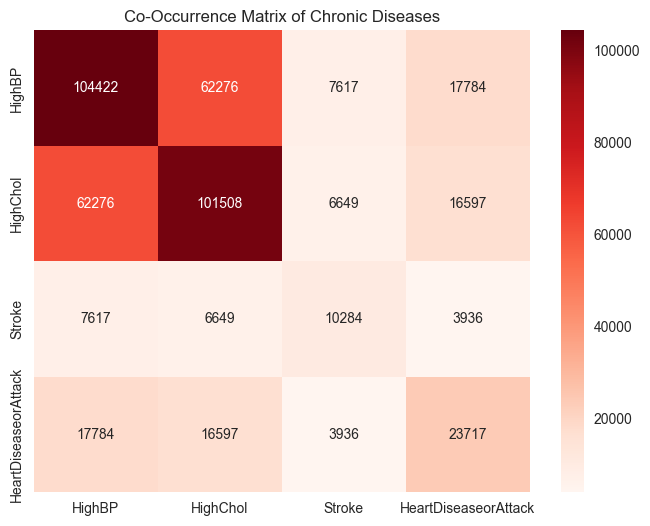

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(co_matrix, annot=True, cmap="Reds", fmt="g")
plt.title("Co-Occurrence Matrix of Chronic Diseases")
plt.show()

In [6]:
G = nx.from_pandas_adjacency(co_matrix)
G

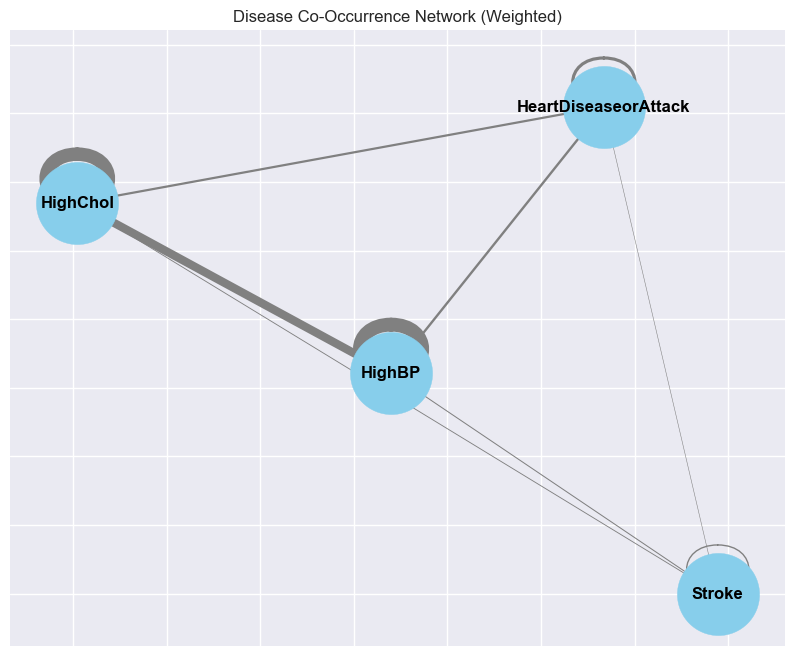

In [7]:
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)

# Extract edge weights directly
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]   # no division

# Normalize for plotting (thicker lines)
norm_weights = [w / max(weights) * 10 for w in weights]

nx.draw_networkx_nodes(G, pos,
                       node_size=3500,
                       node_color="skyblue")

nx.draw_networkx_labels(G, pos,
                        font_size=12,
                        font_weight='bold')

nx.draw_networkx_edges(G, pos,
                       width=norm_weights,
                       edge_color='gray')

plt.title("Disease Co-Occurrence Network (Weighted)")
plt.savefig("../results/figures/network_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
degree_cent = nx.degree_centrality(G)
degree_cent

{'HighBP': 1.6666666666666665,
 'HighChol': 1.6666666666666665,
 'Stroke': 1.6666666666666665,
 'HeartDiseaseorAttack': 1.6666666666666665}

In [9]:
bet_cent = nx.betweenness_centrality(G, normalized=True)
bet_cent

{'HighBP': 0.0, 'HighChol': 0.0, 'Stroke': 0.0, 'HeartDiseaseorAttack': 0.0}

In [10]:
close_cent = nx.closeness_centrality(G)
close_cent

{'HighBP': 1.0, 'HighChol': 1.0, 'Stroke': 1.0, 'HeartDiseaseorAttack': 1.0}

In [11]:
metrics_df = pd.DataFrame({
    'Degree Centrality': degree_cent,
    'Betweenness Centrality': bet_cent,
    'Closeness Centrality': close_cent
})

metrics_df

,Degree Centrality,Betweenness Centrality,Closeness Centrality
HighBP,1.666667,0.0,1.0
HighChol,1.666667,0.0,1.0
Stroke,1.666667,0.0,1.0
HeartDiseaseorAttack,1.666667,0.0,1.0


### Interpretation of Network Metrics

- HighBP and HighChol are the largest, most connected nodes.
    → They dominate the comorbidity landscape.
- HeartDiseaseorAttack is centrally connected to both HighBP and HighChol
    → Representing a dependent relationship on these risk factors.
- Stroke appears at the edge of the network
    → Connected, but less frequently co-occurring.

This helps us understand which diseases are key drivers of comorbidity risk.

### Interpretation of Centrality Metrics

All four diseases show the same values for:
- Degree Centrality
- Closeness Centrality
- Betweenness Centrality

This occurs because: The graph is fully connected — each disease is directly linked to all three others.

However:
The edge weights reveal the true differences.

HighBP and HighChol have much stronger weighted connections, making them more influential even if centrality scores appear equal.

In [12]:
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/graphs", exist_ok=True)

metrics_df.to_csv("../results/tables/network_metrics.csv")
co_matrix.to_csv("../results/tables/co_occurrence_matrix.csv")

nx.write_gexf(G, "../results/graphs/disease_network.gexf")

### Summary of Findings

- HighBP & HighChol is the strongest comorbid pair, forming the core of the network.
- HeartDiseaseorAttack is strongly linked to both of them, confirming cardiovascular risk clustering.
- Stroke is linked but less central.
- The network confirms known medical patterns of comorbidity among chronic cardiovascular conditions.
- Weighted edges provide deeper insights than centrality scores in this fully connected graph.